# Эксперимент: Оценка робастности детектора AI-текста
## Тестирование робастности на смене домена и языка
  
---

### Дизайн эксперимента

| Сценарий | Датасет | Домен | Язык | Ожидание |
|----------|---------|-------|------|----------|
| **In-domain** | `ai_detection_ru_dataset_v4.csv` | Новости | RU | Лучший результат (train=test domain) |
| **Domain shift** | `AINL-Eval-2025 RU_abstracts.csv` | Академический | RU | Падение у лексических baseline |
| **Language shift** | `H3_wiki_csai.jsonl` | Энциклопедический | EN | Падение у спецмоделей, устойчивость синтаксиса |

**Ключевой тезис:** синтаксический метод (основной, `AICoreDetector`) оперирует
универсальными лингвистическими структурами — POS-последовательностями, деревьями
зависимостей, пунктуационной энтропией — которые не привязаны к конкретному словарю.
Это должно обеспечить более высокую робастность.

## 0. Инициализация

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Путь к корню проекта
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

from src.features import get_syntactic_features, FEATURE_NAMES, N_FEATURES
from src.model import AICoreDetector
from baselines.baselines import (
    TfidfRFDetector, TfidfLogRegDetector,
    StyloRFDetector, StyloLogRegDetector,
    compute_metrics,
)

# --- Пути ---
DATA_DIR    = 'data'
CACHE_DIR   = 'cache'
FIGURES_DIR = 'figures'
OUTPUT_DIR  = os.path.join('baselines', 'output')
os.makedirs(CACHE_DIR,   exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)

# --- Стиль ---
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 12})
sns.set_theme(style='whitegrid')

# Цвета методов (единая палитра на все графики)
METHOD_COLORS = {
    'AICoreDetector (Syntactic)': '#d62728',   # красный — наш метод
    'TF-IDF + Random Forest':     '#1f77b4',
    'TF-IDF + Logistic Regression': '#ff7f0e',
    'Stylometry + Random Forest': '#2ca02c',
    'Stylometry + Logistic Regression': '#9467bd',
}

print('Импорты успешны.')
print(f'Признаков в основном методе: {N_FEATURES}')

Импорты успешны.
Признаков в основном методе: 15


## 1. Загрузка и подготовка данных

In [2]:
# =====================================================================
# 1A. In-domain датасет (тот же, что использовался для обучения)
# =====================================================================
df_main = pd.read_csv(os.path.join(DATA_DIR, 'ai_detection_ru_dataset_v4.csv'))
df_main = df_main.dropna(subset=['text'])
df_main = df_main[df_main['text'].str.len() >= 100].reset_index(drop=True)
df_main['is_ai'] = df_main['is_ai'].astype(int)

print(f'[In-domain]    Записей: {len(df_main):,}  '
      f'(Human={sum(df_main.is_ai==0):,}, AI={sum(df_main.is_ai==1):,})')

# =====================================================================
# 1B. AINL-Eval-2025 — русский академический текст (domain shift)
# =====================================================================
# Формат: text, label  где label ∈ {gpt-4-turbo, llama-3.3-70b, gemma-2-27b, human}
AINL_N = 1000  # на каждый класс

ainl_path = os.path.join(DATA_DIR, 'RU_abstracts.csv')
df_ainl_raw = pd.read_csv(ainl_path)
df_ainl_raw = df_ainl_raw.dropna(subset=['text', 'label'])
df_ainl_raw = df_ainl_raw[df_ainl_raw['text'].str.len() >= 100].reset_index(drop=True)

# Бинаризация: human → 0, все AI-модели → 1
df_ainl_raw['is_ai'] = (df_ainl_raw['label'] != 'human').astype(int)

# Сбалансированная тестовая выборка: 1000 human + 1000 AI
ainl_human = df_ainl_raw[df_ainl_raw['is_ai'] == 0].sample(
    n=min(AINL_N, sum(df_ainl_raw['is_ai'] == 0)), random_state=42
)[['text', 'is_ai']]
ainl_ai = df_ainl_raw[df_ainl_raw['is_ai'] == 1].sample(
    n=min(AINL_N, sum(df_ainl_raw['is_ai'] == 1)), random_state=42
)[['text', 'is_ai']]
df_ainl = pd.concat([ainl_human, ainl_ai], ignore_index=True)
df_ainl['is_ai'] = df_ainl['is_ai'].astype(int)

print(f'[Domain shift] Записей: {len(df_ainl):,}  '
      f'(Human={sum(df_ainl.is_ai==0):,}, AI={sum(df_ainl.is_ai==1):,})')
print(f'  Источник: RU_abstracts.csv (академический RU)')
print(f'  Распределение AI-моделей в выборке:')
print(df_ainl_raw[df_ainl_raw['is_ai']==1]['label'].value_counts().to_string())

# =====================================================================
# 1C. H3 wiki_csai — английский энциклопедический (language shift)
# =====================================================================
wiki_path = os.path.join(DATA_DIR, 'wiki_csai.jsonl')
records = []
with open(wiki_path, 'r', encoding='utf-8') as f:
    for line in f:
        obj = json.loads(line.strip())
        for ans in obj.get('human_answers', []):
            if isinstance(ans, str) and len(ans) >= 100:
                records.append({'text': ans.strip(), 'is_ai': 0})
        for ans in obj.get('chatgpt_answers', []):
            if isinstance(ans, str) and len(ans) >= 100:
                records.append({'text': ans.strip(), 'is_ai': 1})

df_wiki = pd.DataFrame(records)
WIKI_N = 1000
n_min = min(sum(df_wiki.is_ai==0), sum(df_wiki.is_ai==1), WIKI_N)
df_wiki = pd.concat([
    df_wiki[df_wiki.is_ai==0].sample(n_min, random_state=42),
    df_wiki[df_wiki.is_ai==1].sample(n_min, random_state=42),
], ignore_index=True)

print(f'[Lang shift]   Записей: {len(df_wiki):,}  '
      f'(Human={sum(df_wiki.is_ai==0):,}, AI={sum(df_wiki.is_ai==1):,})')
print(f'  Источник: H3 wiki_csai (энциклопедический EN)')


[In-domain]    Записей: 9,995  (Human=4,999, AI=4,996)
[Domain shift] Записей: 2,000  (Human=1,000, AI=1,000)
  Источник: RU_abstracts.csv (академический RU)
  Распределение AI-моделей в выборке:
label
gpt-4-turbo      8801
llama-3.3-70b    8798
gemma-2-27b      8790
[Lang shift]   Записей: 1,682  (Human=841, AI=841)
  Источник: H3 wiki_csai (энциклопедический EN)


## 2. Обучение всех методов на in-domain данных

In [3]:
# --- Разбивка in-domain на train/test (stratified 80/20) ---
X_text_all = np.array(df_main['text'].tolist(), dtype=object)
y_all = np.array(df_main['is_ai'].tolist(), dtype=int)
X_text_train, X_text_test_indomain, y_train, y_test_indomain = train_test_split(
    X_text_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )
print(f'Train: {len(X_text_train):,}  |  Test: {len(X_text_test_indomain):,}')

print(f'Train (in-domain only): {len(X_text_train):,}  '
      f'(Human={sum(y_train==0):,}, AI={sum(y_train==1):,})')
print(f'Test  (in-domain):      {len(X_text_test_indomain):,}')

# =====================================================================
# 2A. Основной метод: AICoreDetector (синтаксический)
# =====================================================================
print('\n[2A] Обучаем AICoreDetector на in-domain train...')

SYNTACTIC_MODEL_PATH = os.path.join(DATA_DIR, 'syntactic_detector.pkl')
FEAT_CACHE           = os.path.join(CACHE_DIR, 'features_cache.npy')
LABEL_CACHE          = os.path.join(CACHE_DIR, 'labels_cache.npy')

if (os.path.exists(FEAT_CACHE) and os.path.exists(LABEL_CACHE)
        and np.load(FEAT_CACHE, mmap_mode='r').shape[1] == N_FEATURES):
    X_feats_all  = np.load(FEAT_CACHE)
    y_feats_all  = np.load(LABEL_CACHE)
    print(f'  Признаки загружены из кэша: {X_feats_all.shape}')
else:
    print('  Извлекаем признаки через spaCy (ru_core_news_lg)...')
    tqdm.pandas(desc='Парсинг in-domain')
    X_feats_all = np.array(
        df_main['text'].progress_apply(get_syntactic_features).tolist(),
        dtype=np.float32
    )
    y_feats_all = y_all
    X_feats_all = np.nan_to_num(X_feats_all)
    np.save(FEAT_CACHE,  X_feats_all)
    np.save(LABEL_CACHE, y_feats_all)
    print(f'  Сохранено: {X_feats_all.shape}')

# ── Загрузка синтаксической модели ──────────────────────────────
print('\n[2A] Загружаем AICoreDetector из pkl...')
SYNTACTIC_MODEL_PATH = os.path.join(DATA_DIR, 'syntactic_detector.pkl')
FEAT_CACHE  = os.path.join(CACHE_DIR, 'features_cache.npy')
LABEL_CACHE = os.path.join(CACHE_DIR, 'labels_cache.npy')

if os.path.exists(SYNTACTIC_MODEL_PATH):
    detector = AICoreDetector.load(SYNTACTIC_MODEL_PATH)
    print('  Загружена из кэша.')
else:
    print('  pkl не найден — обучаем...')
    if (os.path.exists(FEAT_CACHE) and
            np.load(FEAT_CACHE, mmap_mode='r').shape[1] == N_FEATURES):
        X_feats  = np.load(FEAT_CACHE)
        y_cached = np.load(LABEL_CACHE)
    else:
        tqdm.pandas(desc='Признаки')
        X_feats  = np.array(df_main['text'].progress_apply(
            get_syntactic_features).tolist(), dtype=np.float32)
        y_cached = y_all
        X_feats  = np.nan_to_num(X_feats)
        np.save(FEAT_CACHE,  X_feats)
        np.save(LABEL_CACHE, y_cached)
    Xf_tr, _, yf_tr, _ = train_test_split(
        X_feats, y_cached, test_size=0.2, random_state=42, stratify=y_cached)
    detector = AICoreDetector()
    detector.train(Xf_tr, yf_tr)
    detector.save(SYNTACTIC_MODEL_PATH)
    print('  Обучен и сохранён.')

# =====================================================================
# 2B. Baseline методы — тоже только in-domain train
# =====================================================================
print('\n[2B] Обучаем baseline методы на in-domain train...')

baselines = {
    'TF-IDF + Random Forest':            TfidfRFDetector(),
    'TF-IDF + Logistic Regression':      TfidfLogRegDetector(),
    'Stylometry + Random Forest':        StyloRFDetector(),
    'Stylometry + Logistic Regression':  StyloLogRegDetector(),
}

for name, model in baselines.items():
    model.fit(X_text_train, y_train)
    print(f'  ✓ {name}')

print('\nВсе модели обучены.')


Train: 7,996  |  Test: 1,999
Train (in-domain only): 7,996  (Human=3,999, AI=3,997)
Test  (in-domain):      1,999

[2A] Обучаем AICoreDetector на in-domain train...
  Признаки загружены из кэша: (9995, 15)

[2A] Загружаем AICoreDetector из pkl...
  Загружена из кэша.

[2B] Обучаем baseline методы на in-domain train...
  ✓ TF-IDF + Random Forest
  ✓ TF-IDF + Logistic Regression
  ✓ Stylometry + Random Forest
  ✓ Stylometry + Logistic Regression

Все модели обучены.


## 3. Оценка на трёх сценариях

Для каждого сценария собираем метрики всех 5 методов в единую таблицу.

In [16]:
import hashlib
detector = AICoreDetector.load(SYNTACTIC_MODEL_PATH)
def _texts_hash(texts):
    """Короткий хэш набора текстов для именования кэша."""
    h = hashlib.md5(' '.join(texts[:10]).encode() + str(len(texts)).encode()).hexdigest()[:10]
    return h

def eval_syntactic_on_texts(detector, texts, y_true, cache_tag=''):
    """Оценка AICoreDetector на произвольном наборе текстов.
    Признаки кэшируются в CACHE_DIR по хэшу набора текстов."""
    tag      = cache_tag or _texts_hash(list(texts))
    f_cache  = os.path.join(CACHE_DIR, f'feats_{tag}.npy')

    if os.path.exists(f_cache):
        feats = np.load(f_cache)
        print(f'    Признаки загружены из кэша: {f_cache}')
    else:
        print(f'    Извлечение признаков ({len(texts)} текстов)...')
        feats = np.array(
            [get_syntactic_features(t) for t in tqdm(texts, leave=False)],
            dtype=np.float32
        )
        feats = np.nan_to_num(feats)
        np.save(f_cache, feats)
        print(f'    Признаки сохранены в кэш: {f_cache}')

    y_pred = detector.predict(feats)
    y_prob = detector.predict_proba(feats)[:, 1]
    return compute_metrics(y_true, y_pred, y_prob, 'AICoreDetector (Syntactic)'), y_prob


# Словарь: scenario_name → {method_name → metrics_dict}
# Также сохраняем y_prob для ROC-кривых
all_results   = {}   # {scenario: [metrics_dict, ...]}
all_probs     = {}   # {scenario: {method: (y_true, y_prob)}}

# cache_tag — короткое имя для файла кэша признаков (без пробелов)
SCENARIOS = [
    ('In-domain (RU News)',        X_text_test_indomain,        y_test_indomain,          'indomain'),
    ('Domain shift (RU Academic)', df_ainl['text'].values,      df_ainl['is_ai'].values,  'ainl_dev'),
    ('Language shift (EN Wiki)',   df_wiki['text'].values,       df_wiki['is_ai'].values,  'wiki_csai'),
]

for scenario_name, X_texts, y_true, cache_tag in SCENARIOS:
    print(f'\n=== Сценарий: {scenario_name} (n={len(y_true)}) ===')
    scenario_metrics = []
    scenario_probs   = {}

    # --- Основной метод ---
    print('  [Syntactic]')
    m, y_prob = eval_syntactic_on_texts(detector, X_texts, y_true, cache_tag=cache_tag)
    scenario_metrics.append(m)
    scenario_probs[m['name']] = (y_true, y_prob)
    print(f'    F1={m["F1"]:.4f}  AUC={m["AUC-ROC"]:.4f}')

    # --- Baseline методы ---
    for method_name, model in baselines.items():
        print(f'  [{method_name}]')
        m_bl = model.get_metrics(X_texts, y_true)
        y_prob_bl = model.predict_proba(X_texts)[:, 1]
        scenario_metrics.append(m_bl)
        scenario_probs[method_name] = (y_true, y_prob_bl)
        print(f'    F1={m_bl["F1"]:.4f}  AUC={m_bl["AUC-ROC"]:.4f}')

    all_results[scenario_name] = scenario_metrics
    all_probs[scenario_name]   = scenario_probs

print('\n✓ Оценка завершена.')

scenario_order = [s[0] for s in SCENARIOS]
method_order   = list(METHOD_COLORS.keys())


=== Сценарий: In-domain (RU News) (n=1999) ===
  [Syntactic]
    Признаки загружены из кэша: cache/feats_indomain.npy
    F1=0.8986  AUC=0.9610
  [TF-IDF + Random Forest]
    F1=0.9592  AUC=0.9928
  [TF-IDF + Logistic Regression]
    F1=0.9768  AUC=0.9979
  [Stylometry + Random Forest]
    F1=0.8955  AUC=0.9645
  [Stylometry + Logistic Regression]
    F1=0.8519  AUC=0.9190

=== Сценарий: Domain shift (RU Academic) (n=2000) ===
  [Syntactic]
    Признаки загружены из кэша: cache/feats_ainl_dev.npy
    F1=0.8977  AUC=0.9614
  [TF-IDF + Random Forest]
    F1=0.6915  AUC=0.7157
  [TF-IDF + Logistic Regression]
    F1=0.7313  AUC=0.8371
  [Stylometry + Random Forest]
    F1=0.6731  AUC=0.5988
  [Stylometry + Logistic Regression]
    F1=0.6784  AUC=0.5246

=== Сценарий: Language shift (EN Wiki) (n=1682) ===
  [Syntactic]
    Признаки загружены из кэша: cache/feats_wiki_csai.npy
    F1=0.7411  AUC=0.8915
  [TF-IDF + Random Forest]
    F1=0.6667  AUC=0.6345
  [TF-IDF + Logistic Regression]
  

In [5]:
# --- Сводная таблица результатов ---
rows = []
for scenario, metrics_list in all_results.items():
    for m in metrics_list:
        rows.append({'Сценарий': scenario, **m})

df_results = pd.DataFrame(rows)
df_pivot = df_results.pivot_table(
    index='name', columns='Сценарий',
    values=['F1', 'AUC-ROC', 'Accuracy'], aggfunc='first'
).round(4)

print('\nСводная таблица F1 / AUC-ROC по сценариям:')
display(df_pivot)

# Сохраняем
df_results.to_csv(os.path.join(OUTPUT_DIR, 'robustness_results.csv'), index=False)
print('\nСохранено:', os.path.join(OUTPUT_DIR, 'robustness_results.csv'))


Сводная таблица F1 / AUC-ROC по сценариям:


AUC-ROC  \
Сценарий                         Domain shift (RU Academic)   
name                                                          
AICoreDetector (Syntactic)                           0.9995   
Stylometry + Logistic Regression                     0.5246   
Stylometry + Random Forest                           0.5988   
TF-IDF + Logistic Regression                         0.8371   
TF-IDF + Random Forest                               0.7156   

                                                                               \
Сценарий                         In-domain (RU News) Language shift (EN Wiki)   
name                                                                            
AICoreDetector (Syntactic)                    0.9570                   0.8536   
Stylometry + Logistic Regression              0.9190                   0.6849   
Stylometry + Random Forest                    0.9645                   0.7202   
TF-IDF + Logistic Regression                  0.9979                   0.6578   
TF-IDF + Random Forest                        0.9928                   0.6345   

                                                   Accuracy  \
Сценарий                         Domain shift (RU Academic)   
name                                                          
AICoreDetector (Syntactic)                           0.9870   
Stylometry + Logistic Regression                     0.5435   
Stylometry + Random Forest                           0.5575   
TF-IDF + Logistic Regression                         0.6455   
TF-IDF + Random Forest                               0.6400   

                                                                               \
Сценарий                         In-domain (RU News) Language shift (EN Wiki)   
name                                                                            
AICoreDetector (Syntactic)                    0.8894                   0.7628   
Stylometry + Logistic Regression              0.8534                   0.6094   
Stylometry + Random Forest                    0.8980                   0.6005   
TF-IDF + Logistic Regression                  0.9770                   0.5000   
TF-IDF + Random Forest                        0.9595                   0.5000   

                                                         F1  \
Сценарий                         Domain shift (RU Academic)   
name                                                          
AICoreDetector (Syntactic)                           0.9871   
Stylometry + Logistic Regression                     0.6784   
Stylometry + Random Forest                           0.6731   
TF-IDF + Logistic Regression                         0.7313   
TF-IDF + Random Forest                               0.6915   

                                                                               
Сценарий                         In-domain (RU News) Language shift (EN Wiki)  
name                                                                           
AICoreDetector (Syntactic)                    0.8844                   0.7780  
Stylometry + Logistic Regression              0.8520                   0.7020  
Stylometry + Random Forest                    0.8955                   0.7093  
TF-IDF + Logistic Regression                  0.9768                   0.6667  
TF-IDF + Random Forest                        0.9592                   0.6667


Сохранено: baselines/output/robustness_results.csv


## 4. Визуализация результатов

### 4A. Heatmap деградации качества

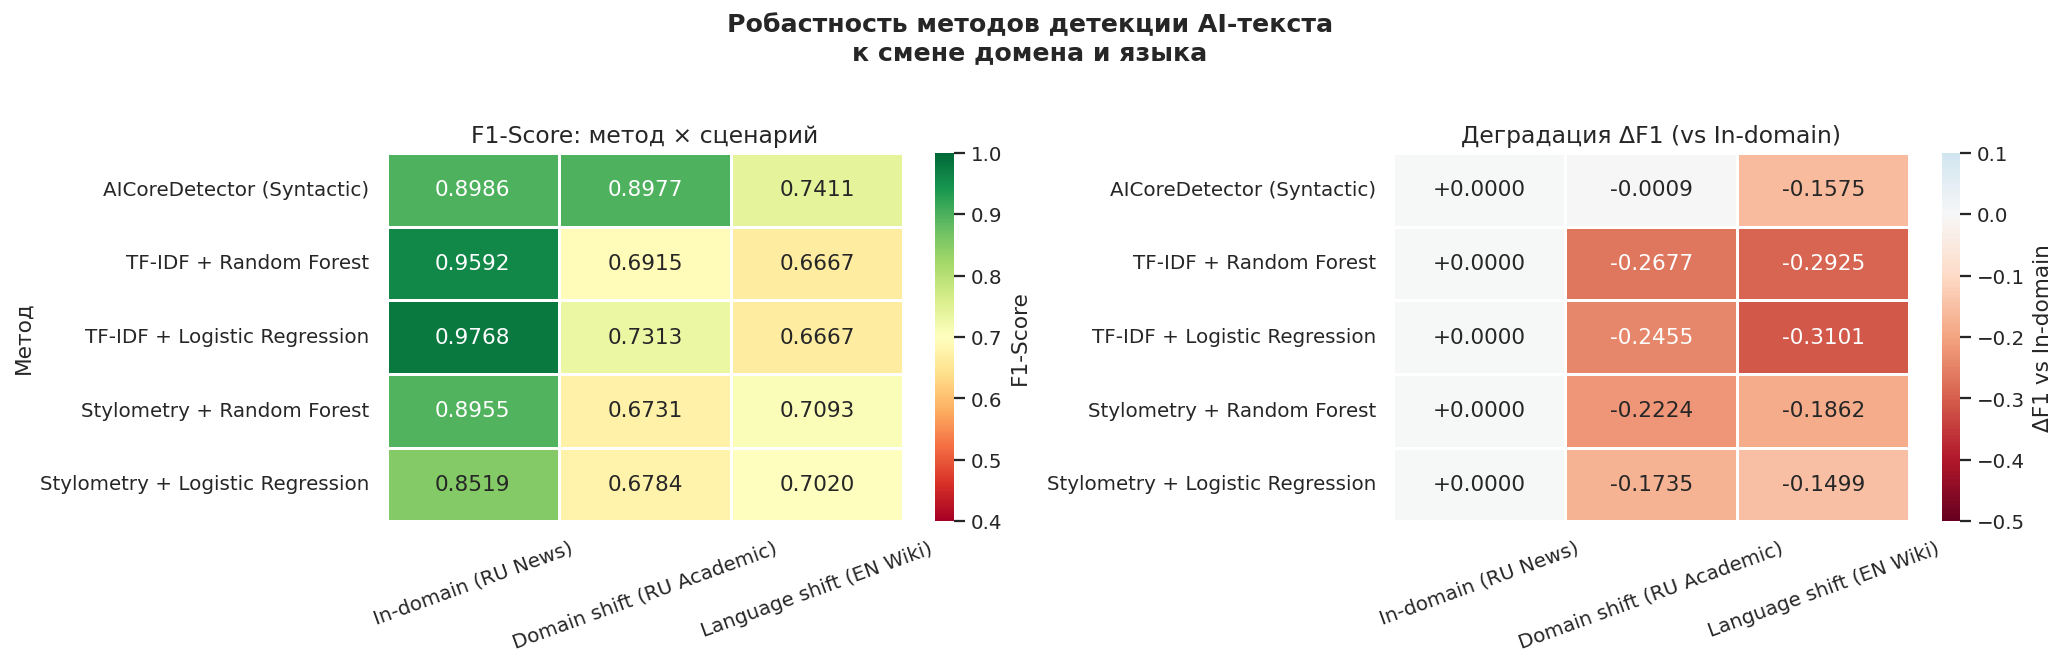

In [17]:
# =====================================================================
# 4A. Heatmap: F1-score по методам × сценариям
# =====================================================================
# Строим матрицу F1
f1_matrix = pd.DataFrame(index=method_order, columns=scenario_order, dtype=float)
for scenario, metrics_list in all_results.items():
    for m in metrics_list:
        if m['name'] in f1_matrix.index:
            f1_matrix.loc[m['name'], scenario] = m['F1']

# Матрица деградации: F1(scenario) - F1(in-domain)
indomain_col   = scenario_order[0]
drop_matrix    = f1_matrix.subtract(f1_matrix[indomain_col], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Абсолютные значения
sns.heatmap(
    f1_matrix.astype(float), annot=True, fmt='.4f', cmap='RdYlGn',
    vmin=0.4, vmax=1.0, linewidths=0.8, ax=axes[0],
    cbar_kws={'label': 'F1-Score'}
)
axes[0].set_title('F1-Score: метод × сценарий', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Метод')
axes[0].tick_params(axis='x', rotation=20)

# Деградация (Δ F1)
sns.heatmap(
    drop_matrix.astype(float), annot=True, fmt='+.4f', cmap='RdBu',
    center=0, vmin=-0.5, vmax=0.1, linewidths=0.8, ax=axes[1],
    cbar_kws={'label': 'ΔF1 vs In-domain'}
)
axes[1].set_title('Деградация ΔF1 (vs In-domain)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Робастность методов детекции AI-текста\n'
             'к смене домена и языка', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'robustness_heatmap.png'), bbox_inches='tight')
plt.show()

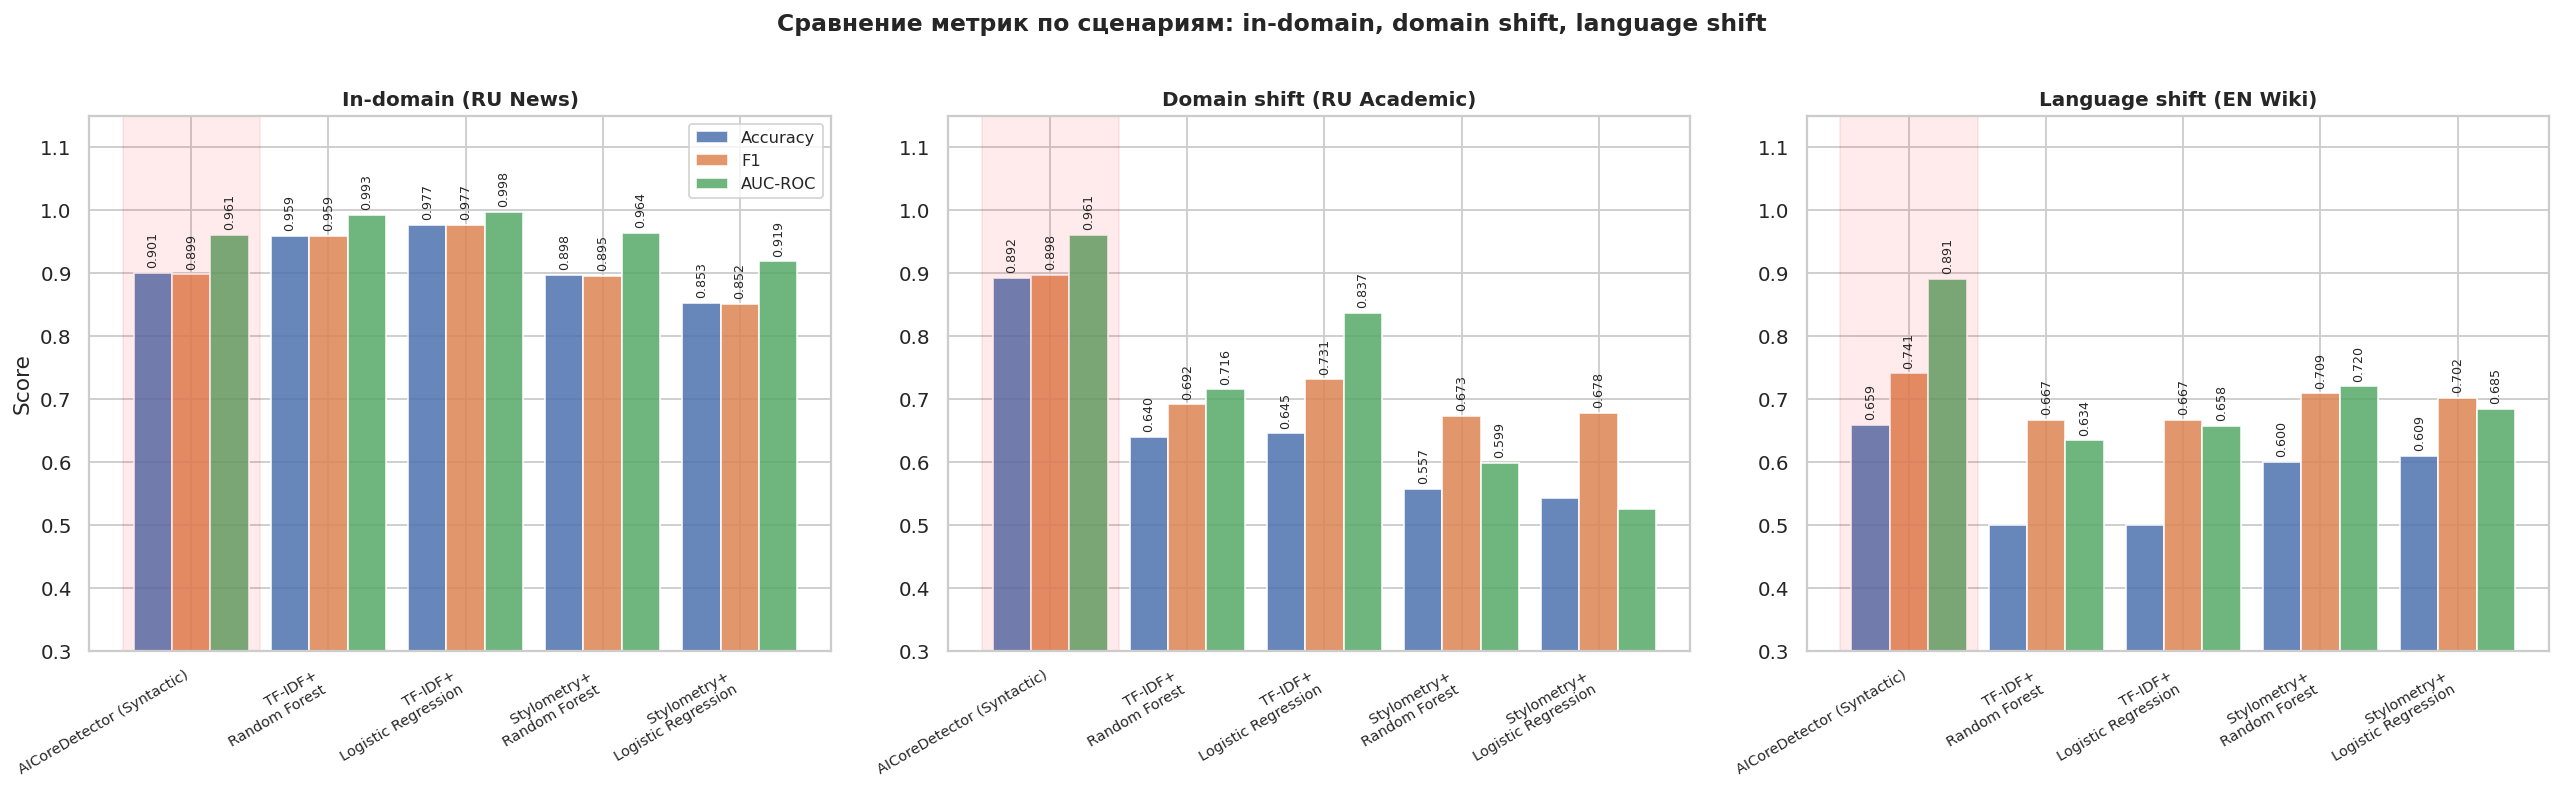

In [18]:
# =====================================================================
# 4B. Grouped bar chart: все метрики по сценариям
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

metrics_to_plot = ['Accuracy', 'F1', 'AUC-ROC']

for ax_idx, (scenario_name, ax) in enumerate(zip(scenario_order, axes)):
    metrics_list = all_results[scenario_name]
    names  = [m['name'] for m in metrics_list]
    colors = [METHOD_COLORS.get(n, '#888888') for n in names]

    x      = np.arange(len(names))
    width  = 0.28
    offsets = [-width, 0, width]

    for i, metric in enumerate(metrics_to_plot):
        vals = [m[metric] for m in metrics_list]
        bars = ax.bar(x + offsets[i], vals, width, label=metric,
                      alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0.55:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' + ', '+\n') for n in names],
                       rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.3, 1.15)
    ax.set_title(scenario_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Score' if ax_idx == 0 else '')
    if ax_idx == 0:
        ax.legend(fontsize=9)

    # Подсветка нашего метода
    for xi, name in enumerate(names):
        if 'Syntactic' in name:
            ax.axvspan(xi - 0.5, xi + 0.5, alpha=0.08, color='red')

fig.suptitle('Сравнение метрик по сценариям: in-domain, domain shift, language shift',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'robustness_bar_chart.png'), bbox_inches='tight')
plt.show()

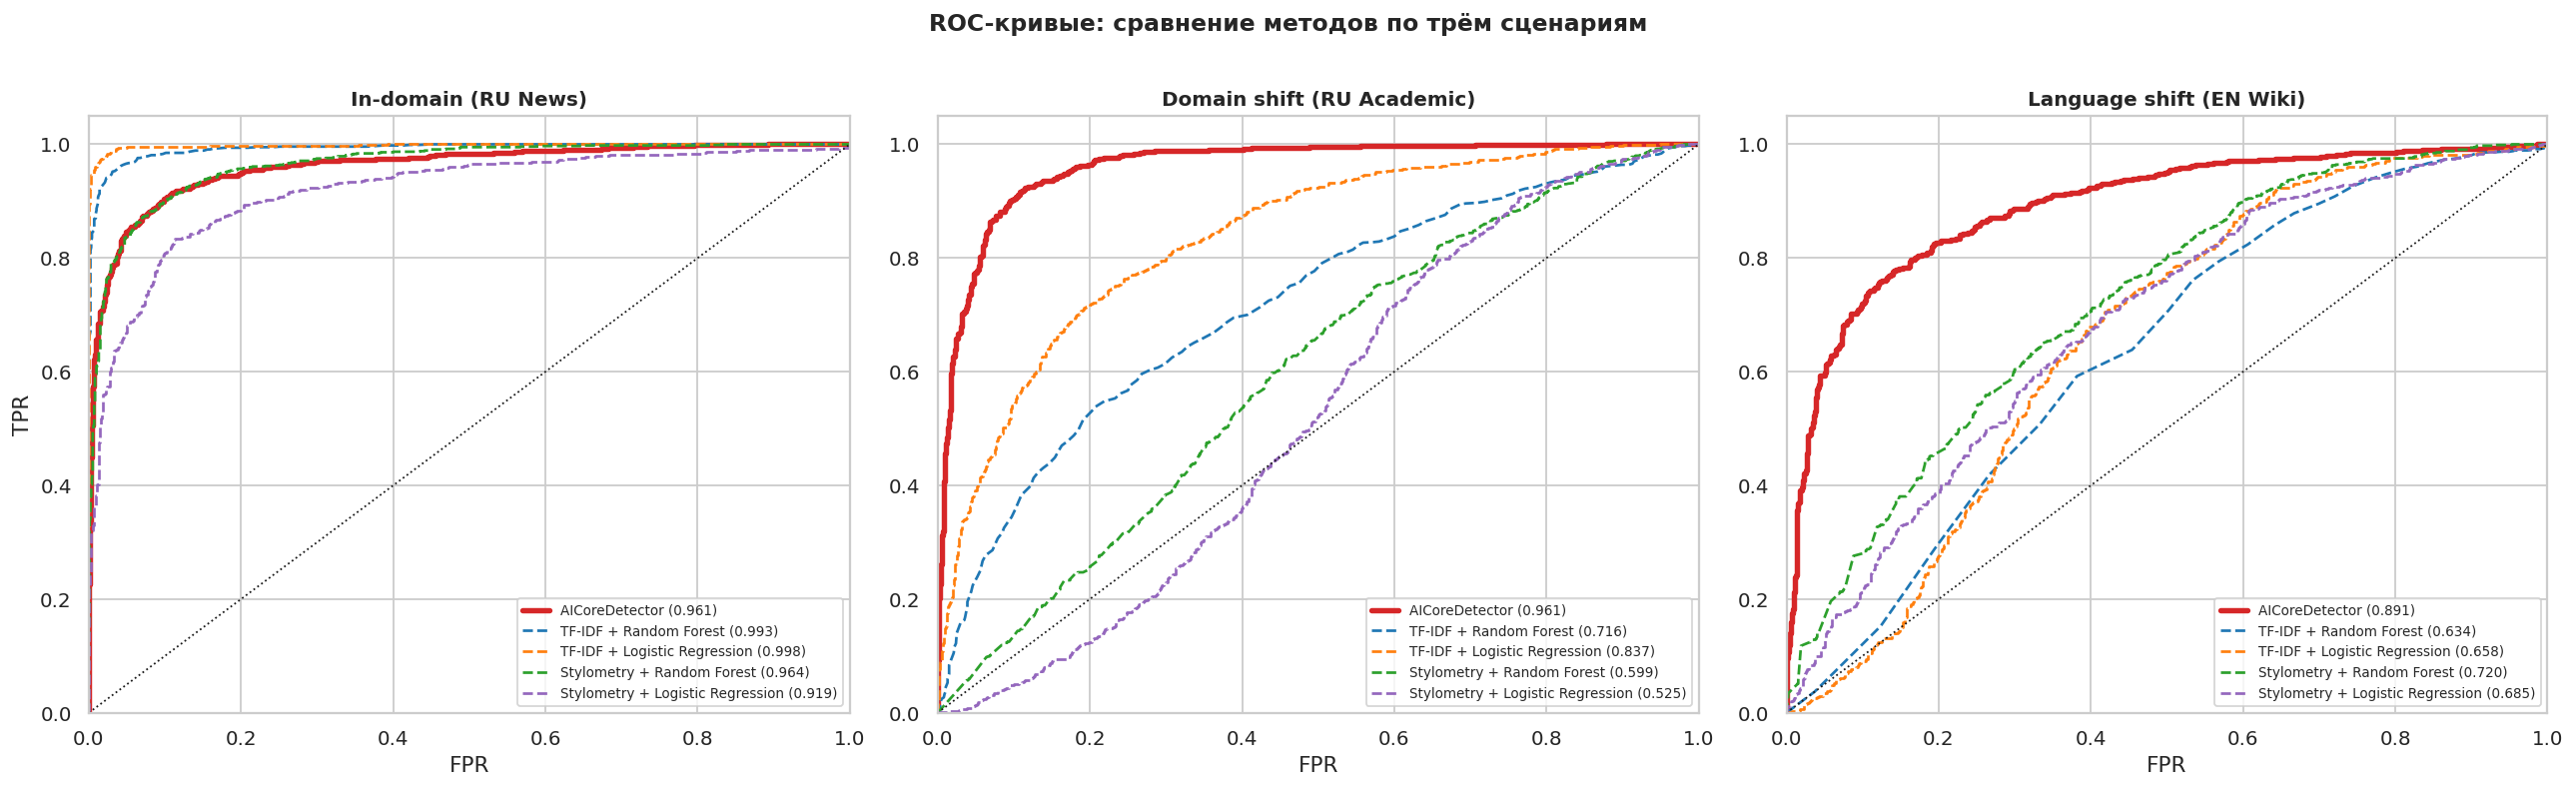

In [19]:
# =====================================================================
# 4C. ROC-кривые: 3 сценария × 5 методов (3 subplots)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, scenario_name in zip(axes, scenario_order):
    probs_dict = all_probs[scenario_name]

    for method_name, (y_true, y_prob) in probs_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc     = auc(fpr, tpr)
        color       = METHOD_COLORS.get(method_name, '#888888')
        lw          = 3.0 if 'Syntactic' in method_name else 1.5
        ls          = '-'  if 'Syntactic' in method_name else '--'
        ax.plot(fpr, tpr, color=color, lw=lw, ls=ls,
                label=f'{method_name.split(" (")[0]} ({roc_auc:.3f})')

    ax.plot([0,1],[0,1], 'k:', lw=1)
    ax.set_title(scenario_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR' if ax == axes[0] else '')
    ax.legend(fontsize=7.5, loc='lower right')
    ax.set_xlim(0,1); ax.set_ylim(0,1.05)

fig.suptitle('ROC-кривые: сравнение методов по трём сценариям', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'robustness_roc_curves.png'), bbox_inches='tight')
plt.show()

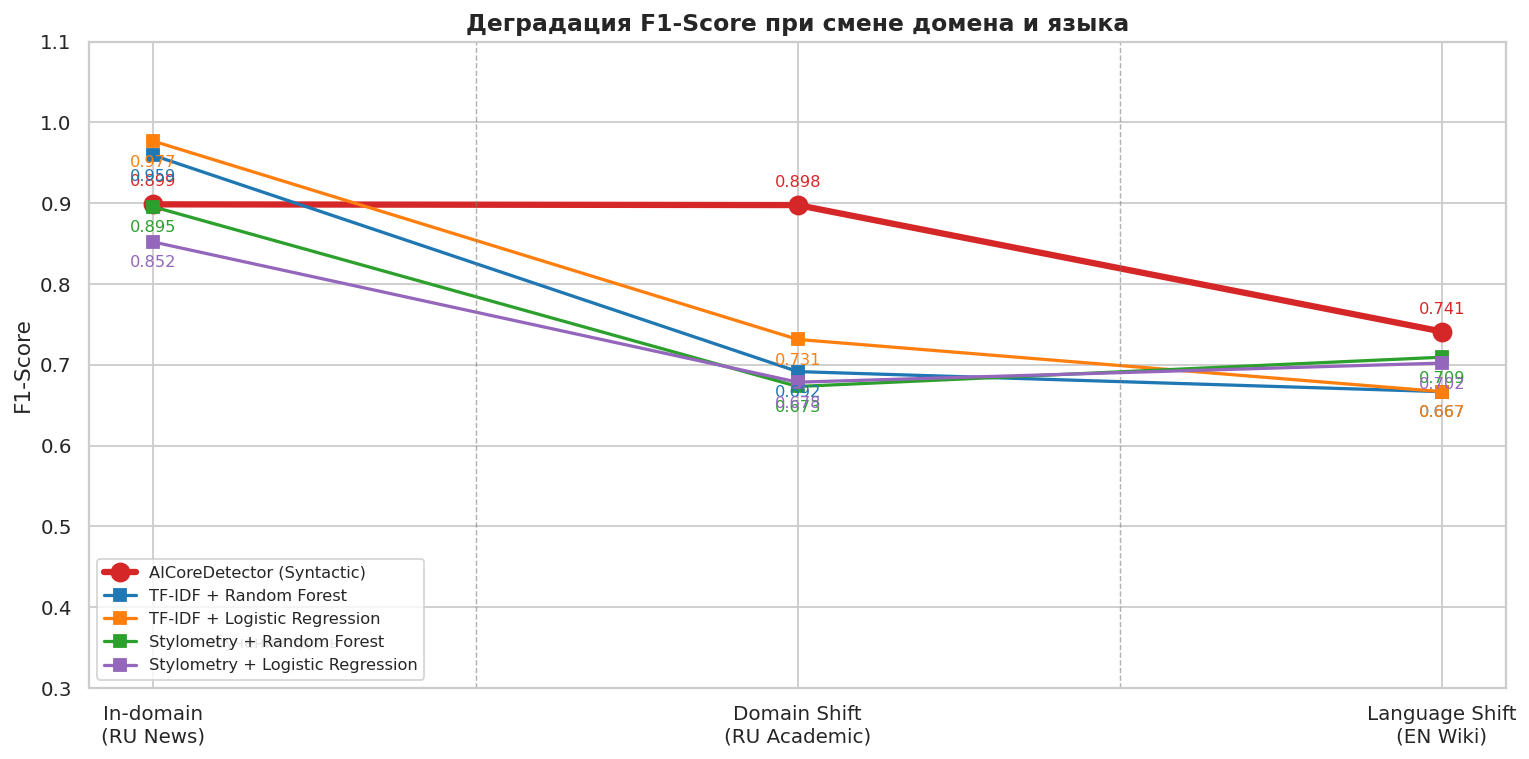

In [20]:
# =====================================================================
# 4D. Линейный график деградации F1 по сценариям
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 6))

x_ticks = list(range(len(scenario_order)))

for method_name in method_order:
    f1_vals = []
    for scenario in scenario_order:
        for m in all_results[scenario]:
            if m['name'] == method_name:
                f1_vals.append(m['F1'])
                break
    if len(f1_vals) == len(scenario_order):
        color = METHOD_COLORS.get(method_name, '#888888')
        lw    = 3.5 if 'Syntactic' in method_name else 1.8
        ms    = 10  if 'Syntactic' in method_name else 7
        marker = 'o' if 'Syntactic' in method_name else 's'
        ax.plot(x_ticks, f1_vals, color=color, lw=lw,
                marker=marker, markersize=ms, label=method_name)
        for xi, v in zip(x_ticks, f1_vals):
            ax.annotate(f'{v:.3f}', (xi, v),
                        textcoords='offset points',
                        xytext=(0, 10 if 'Syntactic' in method_name else -14),
                        ha='center', fontsize=9, color=color)

ax.set_xticks(x_ticks)
ax.set_xticklabels([
    'In-domain\n(RU News)',
    'Domain Shift\n(RU Academic)',
    'Language Shift\n(EN Wiki)'
], fontsize=11)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_ylim(0.3, 1.1)
ax.set_title('Деградация F1-Score при смене домена и языка',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.axvline(x=0.5, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.axvline(x=1.5, color='gray', ls='--', lw=0.8, alpha=0.6)

# Стрелки-аннотации смены условий
ax.annotate('← обучение здесь', xy=(0.05, 0.35), fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'robustness_f1_degradation.png'), bbox_inches='tight')
plt.show()

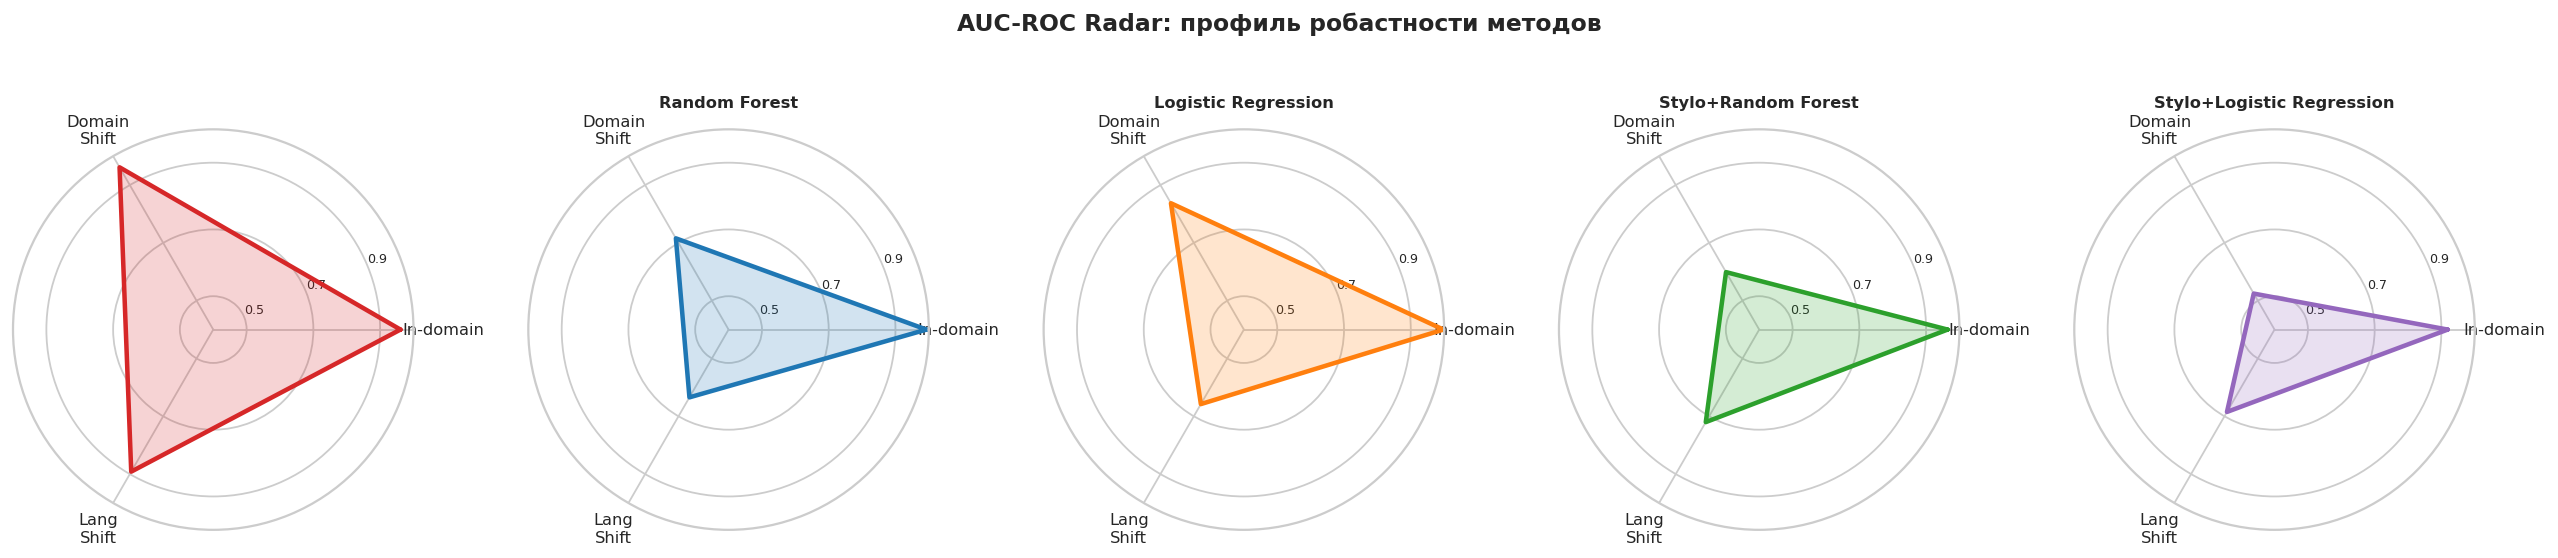

In [21]:
# =====================================================================
# 4E. Radar / Spider chart — профиль каждого метода по 3 сценариям
# =====================================================================
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

# Используем AUC-ROC для radar
auc_matrix = pd.DataFrame(index=method_order, columns=scenario_order, dtype=float)
for scenario, metrics_list in all_results.items():
    for m in metrics_list:
        if m['name'] in auc_matrix.index:
            auc_matrix.loc[m['name'], scenario] = m['AUC-ROC']

labels   = ['In-domain', 'Domain\nShift', 'Lang\nShift']
N_axes   = len(labels)
angles   = np.linspace(0, 2*np.pi, N_axes, endpoint=False).tolist()
angles  += angles[:1]  # замыкаем

fig, axes_r = plt.subplots(1, len(method_order), figsize=(20, 4),
                            subplot_kw=dict(polar=True))

for ax_r, method_name in zip(axes_r, method_order):
    vals = auc_matrix.loc[method_name].values.tolist()
    vals += vals[:1]

    color = METHOD_COLORS.get(method_name, '#888')
    ax_r.plot(angles, vals, color=color, lw=2.5)
    ax_r.fill(angles, vals, color=color, alpha=0.2)

    ax_r.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
    ax_r.set_ylim(0.4, 1.0)
    ax_r.set_yticks([0.5, 0.7, 0.9])
    ax_r.set_yticklabels(['0.5', '0.7', '0.9'], fontsize=7)
    short = method_name.replace('TF-IDF + ','').replace(
        'Stylometry + ','Stylo+').replace('AICoreDetector ','').replace('(Syntactic)','')
    ax_r.set_title(short.strip(), fontsize=9, fontweight='bold', pad=12)

fig.suptitle('AUC-ROC Radar: профиль робастности методов',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'robustness_radar.png'), bbox_inches='tight')
plt.show()

## 5. Анализ: почему синтаксический метод более робастен?

Вычисляем признаки для AINL датасета...
  Загружено из кэша: cache/feats_ainl_dev.npy


/tmp/ipykernel_1995140/414856041.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1995140/414856041.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1995140/414856041.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1995140/414856041.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1995140/414856041.py:

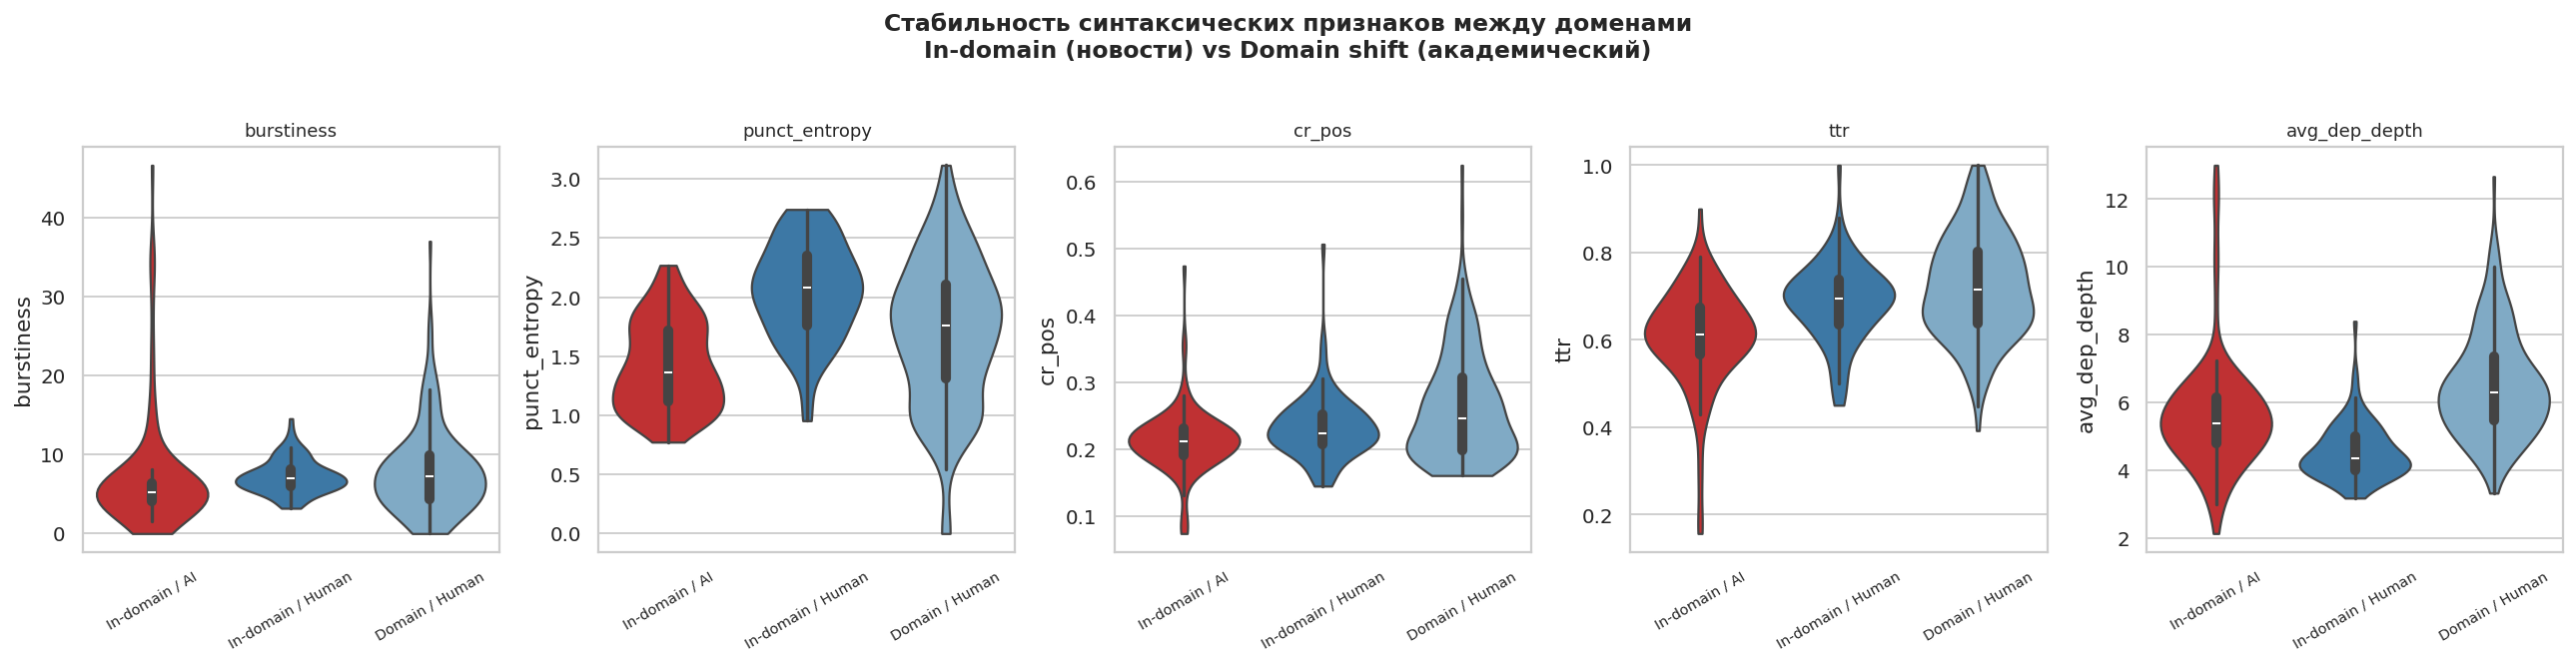

In [22]:
# =====================================================================
# 5A. Сравнение распределений признаков: in-domain vs domain shift
# =====================================================================
# Показываем, что ключевые синтаксические признаки стабильны между доменами
# (в отличие от лексических TF-IDF)

TOP_FEATS = ['burstiness', 'punct_entropy', 'cr_pos', 'ttr', 'avg_dep_depth']

print('Вычисляем признаки для AINL датасета...')
_ainl_5a_cache = os.path.join(CACHE_DIR, 'feats_ainl_dev.npy')
if os.path.exists(_ainl_5a_cache):
    feats_ainl = np.load(_ainl_5a_cache)[:200]
    print(f'  Загружено из кэша: {_ainl_5a_cache}')
else:
    feats_ainl = np.array(
        [get_syntactic_features(t) for t in tqdm(df_ainl['text'].values[:200], leave=True)],
        dtype=np.float32
    )
    feats_ainl = np.nan_to_num(feats_ainl)
    # Примечание: полный кэш уже создан в секции 3 (feats_ainl_dev.npy)
    # Этот блок выполнится только если секция 3 ещё не запускалась
y_ainl_sub = df_ainl['is_ai'].values[:200]

# Загружаем in-domain признаки
X_all_feats = np.load(FEAT_CACHE)
feat_df_indomain = pd.DataFrame(X_all_feats, columns=FEATURE_NAMES)
feat_df_indomain['is_ai'] = y_all
feat_df_indomain['domain'] = 'In-domain (RU News)'

feat_df_ainl = pd.DataFrame(feats_ainl, columns=FEATURE_NAMES)
feat_df_ainl['is_ai'] = y_ainl_sub
feat_df_ainl['domain'] = 'Domain Shift (RU Academic)'

feat_combined = pd.concat([
    feat_df_indomain.sample(200, random_state=42),
    feat_df_ainl
], ignore_index=True)
feat_combined['class'] = feat_combined.apply(
    lambda r: f"{r['domain'].split(' ')[0]} / {'AI' if r['is_ai'] else 'Human'}", axis=1
)

fig, axes = plt.subplots(1, len(TOP_FEATS), figsize=(20, 5))
palette_cross = {
    'In-domain / Human':         '#2c7bb6',
    'In-domain / AI':            '#d7191c',
    'Domain / Human':            '#74add1',
    'Domain / AI':               '#f46d43',
}

for ax, feat in zip(axes, TOP_FEATS):
    sns.violinplot(
        data=feat_combined, x='class', y=feat, ax=ax,
        palette=palette_cross, inner='box', cut=0
    )
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

fig.suptitle('Стабильность синтаксических признаков между доменами\n'
             'In-domain (новости) vs Domain shift (академический)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_stability_cross_domain.png'),
            bbox_inches='tight')
plt.show()

## 6. Итоговый дашборд

In [24]:
# =====================================================================
# 6. Итоговая сводная таблица
# =====================================================================
print('=' * 80)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА РОБАСТНОСТИ')
print('=' * 80)

for scenario in scenario_order:
    print(f'\n  Сценарий: {scenario}')
    print(f'  {"Метод":<40} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7}')
    print('  ' + '-' * 73)
    for m in sorted(all_results[scenario], key=lambda x: -x['F1']):
        marker = ' ◄' if 'Syntactic' in m['name'] else '  '
        print(f'  {m["name"]:<40} '
              f'{m["Accuracy"]:>7.4f} {m["Precision"]:>7.4f} '
              f'{m["Recall"]:>7.4f} {m["F1"]:>7.4f} '
              f'{m["AUC-ROC"]:>7.4f}{marker}')

print('\n' + '=' * 80)
print('◄ = предлагаемый метод (основной)')

# --- Деградация F1 vs In-domain ---
indomain_scenario = scenario_order[0]
print('\n  Деградация F1 (vs In-domain):')
header = f'  {"Метод":<40}' + ''.join(f'  {s[:12]:>14}' for s in scenario_order[1:])
print(header)
print('  ' + '-' * (40 + 16 * len(scenario_order[1:])))

for method in method_order:
    f1_vals = {}
    for scenario in scenario_order:
        for m in all_results[scenario]:
            if m['name'] == method:
                f1_vals[scenario] = m['F1']
    if len(f1_vals) == len(scenario_order):
        marker = ' ◄' if 'Syntactic' in method else ''
        drops = ''.join(
            f'  {f1_vals[s] - f1_vals[indomain_scenario]:>+14.4f}'
            for s in scenario_order[1:])
        print(f'{method:<40}{drops}{marker}')

print('\nГрафики сохранены в:', FIGURES_DIR)

ИТОГОВЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА РОБАСТНОСТИ

  Сценарий: In-domain (RU News)
  Метод                                        Acc    Prec     Rec      F1     AUC
  -------------------------------------------------------------------------
  TF-IDF + Logistic Regression              0.9770  0.9847  0.9690  0.9768  0.9979  
  TF-IDF + Random Forest                    0.9595  0.9655  0.9529  0.9592  0.9928  
  AICoreDetector (Syntactic)                0.9010  0.9203  0.8779  0.8986  0.9610 ◄
  Stylometry + Random Forest                0.8980  0.9171  0.8749  0.8955  0.9645  
  Stylometry + Logistic Regression          0.8534  0.8602  0.8438  0.8519  0.9190  

  Сценарий: Domain shift (RU Academic)
  Метод                                        Acc    Prec     Rec      F1     AUC
  -------------------------------------------------------------------------
  AICoreDetector (Syntactic)                0.8925  0.8565  0.9430  0.8977  0.9614 ◄
  TF-IDF + Logistic Regression              0.6455  0.